
# Module 8 Session 3
## Transfer Learning & Fine-Tuning


## Exercise 1 — Conceptual Answers

### 1. Why freeze early layers?
Early CNN layers detect:
- edges
- textures
- simple patterns  

These are universal across tasks → freezing prevents overfitting and speeds training.

---

### 2. Data augmentation (satellite pools)

**Best:**
- Rotation (0–360°)
- Brightness/contrast
- Flipping

**Worst:**
- Cropping → may remove pool

---

### 3. Medical X-rays
Use **full fine-tuning** because:
- domain differs from ImageNet

Important:
- very small learning rate (e.g., 1e-5)


In [10]:

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


cpu


In [11]:

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2,0.2,0.2,0.1),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
])

train_ds = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
val_ds = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=val_transform)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=64)


In [12]:

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze all
for p in model.parameters():
    p.requires_grad = False

# Replace head
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)


In [13]:

def train_epoch():
    model.train()
    correct,total=0,0
    for x,y in train_loader:
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out,y)
        loss.backward()
        optimizer.step()
        _,pred = out.max(1)
        total+=y.size(0)
        correct+=pred.eq(y).sum().item()
    return correct/total

def validate():
    model.eval()
    correct,total=0,0
    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device), y.to(device)
            out = model(x)
            _,pred = out.max(1)
            total+=y.size(0)
            correct+=pred.eq(y).sum().item()
    return correct/total


In [14]:

train_accs=[]
val_accs=[]

for epoch in range(5):
    ta = train_epoch()
    va = validate()
    train_accs.append(ta)
    val_accs.append(va)
    print(epoch, ta, va)


0 0.32146 0.3948
1 0.35686 0.4022
2 0.36494 0.3952
3 0.36928 0.3952
4 0.3697 0.4153


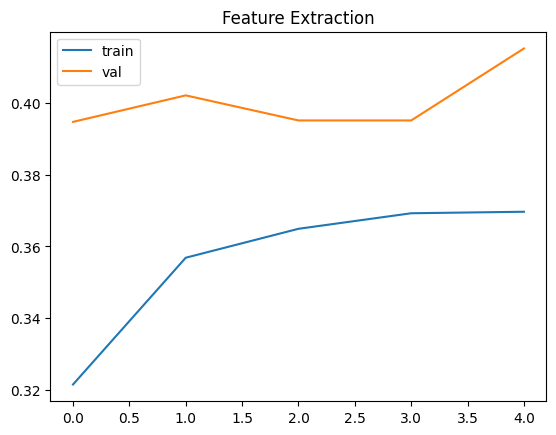

In [15]:

plt.plot(train_accs,label='train')
plt.plot(val_accs,label='val')
plt.legend()
plt.title("Feature Extraction")
plt.show()


In [16]:

# Unfreeze last layers
for name,p in model.named_parameters():
    if 'layer4' in name:
        p.requires_grad=True

optimizer = optim.Adam(model.parameters(), lr=1e-4)

ft_accs=[]
for epoch in range(5):
    ta = train_epoch()
    va = validate()
    ft_accs.append(va)
    print("FT", epoch, va)


FT 0 0.5553
FT 1 0.6086
FT 2 0.6377
FT 3 0.6532
FT 4 0.6584


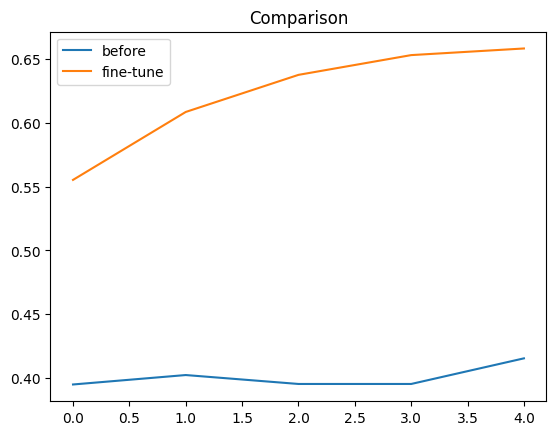

In [17]:

plt.plot(val_accs,label='before')
plt.plot(ft_accs,label='fine-tune')
plt.legend()
plt.title("Comparison")
plt.show()
